In [60]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           balanced_accuracy_score, f1_score, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
import joblib

# Advanced ML libraries
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Install with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install with: pip install lightgbm")

# Explainability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Install with: pip install shap")

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")
print(f"SHAP available: {SHAP_AVAILABLE}")


XGBoost not available. Install with: pip install xgboost
LightGBM not available. Install with: pip install lightgbm
SHAP not available. Install with: pip install shap
Libraries imported successfully!
XGBoost available: False
LightGBM available: False
SHAP available: False


In [61]:
# Load preprocessed datasets
print("LOADING PREPROCESSED DATA")

try:
    # Load preprocessed datasets
    X_train = pd.read_csv('X_train.csv')
    X_val = pd.read_csv('X_val.csv')
    X_test = pd.read_csv('X_test.csv')
    
    y_train = pd.read_csv('y_train.csv').squeeze()
    y_val = pd.read_csv('y_val.csv').squeeze()
    y_test = pd.read_csv('y_test.csv').squeeze()
    ### The .squeeze() method removes dimensions of size 1, converting a DataFrame to a Series
    ### The .squeeze() method is a clean, robust way to ensure your target variables are in the correct 1D format that sklearn expects, 
    ### preventing potential errors during model training and evaluation.
    
    # Load preprocessing objects
    onehot = joblib.load('onehot.pk1')
    ordinalencoder = joblib.load('ordinalencoder.pk1')
    labelencoder = joblib.load('labelencoder.pk1')
    
    scaler = joblib.load('standardscaler.pk1')
    selected_features = joblib.load('selectedfeatures.pk1')
    
    print("...Preprocessed data loaded successfully!!....")
    print(f"Training set: {X_train.shape}")
    print(f"Validation set: {X_val.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Display class distribution
    print("\nClass distribution:")
    print("Training set:")
    print(y_train.value_counts().sort_index())
    print("\nValidation set:")
    print(y_val.value_counts().sort_index())
    print("\nTest set:")
    print(y_test.value_counts().sort_index())
    
    # Display selected features
    print(f"\nSelected features ({len(selected_features)}):")
    for i, feature in enumerate(selected_features, 1):
        print(f"{i:2d}. {feature}")

except FileNotFoundError as e:
    print(f"Error loading preprocessed data: {e}")
    print("Please run the preprocessing notebook first to generate the required files.")
    print("Required files: X_train_scaled.csv, X_val_scaled.csv, X_test_scaled.csv")
    print("                y_train.csv, y_val.csv, y_test.csv")
    print("                scaler.pkl, selected_features.pkl")


LOADING PREPROCESSED DATA
...Preprocessed data loaded successfully!!....
Training set: (338, 15)
Validation set: (113, 15)
Test set: (113, 15)

Class distribution:
Training set:
Loan_Status
0    107
1    231
Name: count, dtype: int64

Validation set:
Loan_Status
0    36
1    77
Name: count, dtype: int64

Test set:
Loan_Status
0    36
1    77
Name: count, dtype: int64

Selected features (10):
 1. Credit_History
 2. Education
 3. Married
 4. Dependents
 5. Loan_Amount_Term_log
 6. CoapplicantIncome_log
 7. ApplicantIncome_log
 8. Gender
 9. Total_Income
10. Loan_to_Income_Ratio


In [62]:
X_val['Gender'].unique()

array([1, 0])

In [63]:
# Baseline Logistic Regression model
print("BASELINE LOGISTIC REGRESSION MODEL")
print("EDA recommendation: Fast, interpretable baseline with coefficients for feature effect direction")

# Create and train baseline model
baseline_model = LogisticRegression(
    random_state=234,
    max_iter=1000,
    class_weight='balanced'  # Handle class imbalance as recommended by EDA
)

# Train the model
baseline_model.fit(X_train, y_train)

# Make predictions
y_train_pred = baseline_model.predict(X_train)
y_val_pred = baseline_model.predict(X_val)
y_test_pred = baseline_model.predict(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred)
val_balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
val_f1 = f1_score(y_val, y_val_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"\nBaseline Model Performance:")
print(f"Training - Accuracy: {train_accuracy:.3f}, Balanced Acc: {train_balanced_acc:.3f}, Macro F1: {train_f1:.3f}")
print(f"Validation - Accuracy: {val_accuracy:.3f}, Balanced Acc: {val_balanced_acc:.3f}, Macro F1: {val_f1:.3f}")
print(f"Test - Accuracy: {test_accuracy:.3f}, Balanced Acc: {test_balanced_acc:.3f}, Macro F1: {test_f1:.3f}")

# Display feature coefficients (interpretability)
print(f"\nFeature Coefficients (Top 10):")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': baseline_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

for i, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']}: {row['coefficient']:.3f}")

# Store baseline results
baseline_results = {
    'model': 'Logistic Regression',
    'train_accuracy': train_accuracy,
    'val_accuracy': val_accuracy,
    'test_accuracy': test_accuracy,
    'train_balanced_acc': train_balanced_acc,
    'val_balanced_acc': val_balanced_acc,
    'test_balanced_acc': test_balanced_acc,
    'train_f1': train_f1,
    'val_f1': val_f1,
    'test_f1': test_f1
}

print(".... Baseline model completed!")


BASELINE LOGISTIC REGRESSION MODEL
EDA recommendation: Fast, interpretable baseline with coefficients for feature effect direction

Baseline Model Performance:
Training - Accuracy: 0.799, Balanced Acc: 0.722, Macro F1: 0.741
Validation - Accuracy: 0.796, Balanced Acc: 0.740, Macro F1: 0.752
Test - Accuracy: 0.743, Balanced Acc: 0.671, Macro F1: 0.681

Feature Coefficients (Top 10):
 1. Credit_History: 3.142
 2. Education: -0.503
 3. Married: 0.391
 4. ApplicantIncome_log: 0.324
 5. Dependents: -0.266
 6. CoapplicantIncome_log: 0.266
 7. LoanAmount_log: -0.240
 8. Total_Income: -0.198
 9. Household_Load: 0.126
10. Loan_Amount_Term_log: -0.083
.... Baseline model completed!


RANDOM FOREST CLASSIFIER
EDA recommendation: Robust, captures interactions, insensitive to scaling and moderate outliers

Random Forest Performance:
Training - Accuracy: 1.000, Balanced Acc: 1.000, Macro F1: 1.000
Validation - Accuracy: 0.743, Balanced Acc: 0.656, Macro F1: 0.667
Test - Accuracy: 0.796, Balanced Acc: 0.703, Macro F1: 0.724

Feature Importance (Top 10):
 1. Credit_History: 0.220
 2. Total_Income: 0.112
 3. Loan_to_Income_Ratio: 0.112
 4. ApplicantIncome_log: 0.105
 5. amountspent_Per_Person: 0.104
 6. LoanAmount_log: 0.103
 7. CoapplicantIncome_log: 0.070
 8. Property_Area: 0.037
 9. Household_Load: 0.029
10. Loan_Amount_Term_log: 0.025


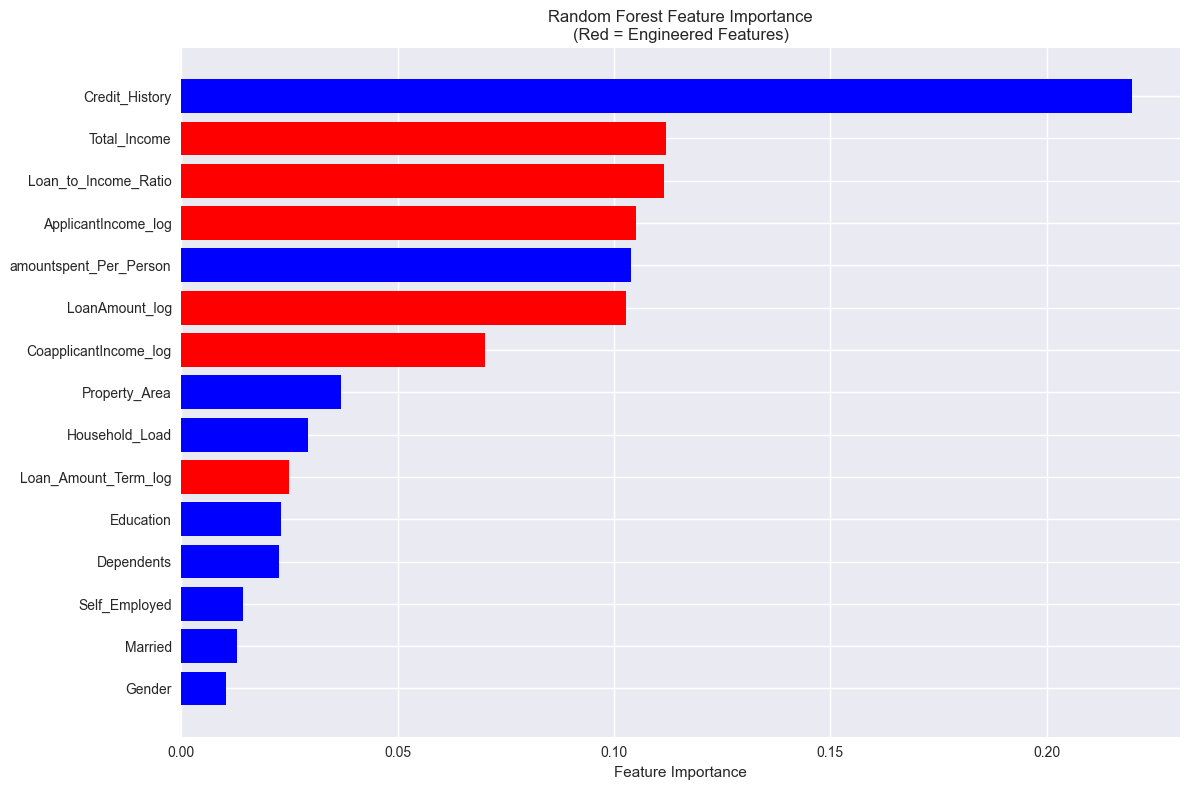

....Random Forest model completed...!


In [64]:
# Random Forest Classifier
print("RANDOM FOREST CLASSIFIER")
print("EDA recommendation: Robust, captures interactions, insensitive to scaling and moderate outliers")

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    n_jobs=-1  # Use all available cores
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

train_balanced_acc_rf = balanced_accuracy_score(y_train, y_train_pred_rf)
val_balanced_acc_rf = balanced_accuracy_score(y_val, y_val_pred_rf)
test_balanced_acc_rf = balanced_accuracy_score(y_test, y_test_pred_rf)

train_f1_rf = f1_score(y_train, y_train_pred_rf, average='macro')
val_f1_rf = f1_score(y_val, y_val_pred_rf, average='macro')
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='macro')

print(f"\nRandom Forest Performance:")
print(f"Training - Accuracy: {train_accuracy_rf:.3f}, Balanced Acc: {train_balanced_acc_rf:.3f}, Macro F1: {train_f1_rf:.3f}")
print(f"Validation - Accuracy: {val_accuracy_rf:.3f}, Balanced Acc: {val_balanced_acc_rf:.3f}, Macro F1: {val_f1_rf:.3f}")
print(f"Test - Accuracy: {test_accuracy_rf:.3f}, Balanced Acc: {test_balanced_acc_rf:.3f}, Macro F1: {test_f1_rf:.3f}")

# Feature importance analysis
print(f"\nFeature Importance (Top 10):")
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

for i, (_, row) in enumerate(feature_importance_rf.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']}: {row['importance']:.3f}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features_rf = feature_importance_rf.head(15)
colors = ['red' if any(keyword in f.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log']) else 'blue' for f in top_features_rf['feature']]

plt.barh(range(len(top_features_rf)), top_features_rf['importance'], color=colors)
plt.yticks(range(len(top_features_rf)), top_features_rf['feature'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance\n(Red = Engineered Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Store Random Forest results
rf_results = {
    'model': 'Random Forest',
    'train_accuracy': train_accuracy_rf,
    'val_accuracy': val_accuracy_rf,
    'test_accuracy': test_accuracy_rf,
    'train_balanced_acc': train_balanced_acc_rf,
    'val_balanced_acc': val_balanced_acc_rf,
    'test_balanced_acc': test_balanced_acc_rf,
    'train_f1': train_f1_rf,
    'val_f1': val_f1_rf,
    'test_f1': test_f1_rf
}

print("....Random Forest model completed...!")


In [65]:


print("LABEL ENCODING FOR XGBOOST COMPATIBILITY")
print("XGBoost requires class labels to start from 0, but wine quality starts from 3")

# Create label encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Fit on all target data to ensure consistent encoding
all_y = pd.concat([y_train, y_val, y_test], ignore_index=True)
label_encoder.fit(all_y)

# Transform all target variables
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"Original classes: {sorted(y_train.unique())}")
print(f"Encoded classes: {sorted(y_train_encoded)}")
print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Display encoded class distribution
print("\nEncoded class distribution:")
print("Training set:")
unique, counts = np.unique(y_train_encoded, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples")

print("Validation set:")
unique, counts = np.unique(y_val_encoded, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples")

print("Test set:")
unique, counts = np.unique(y_test_encoded, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples")

print("Label encoding completed!")


LABEL ENCODING FOR XGBOOST COMPATIBILITY
XGBoost requires class labels to start from 0, but wine quality starts from 3
Original classes: [np.int64(0), np.int64(1)]
Encoded classes: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0),

In [66]:
# XGBoost Classifier
print(".....XGBOOST CLASSIFIER....")
print("EDA recommendation: Best performance for structured data, handles non-linearity and feature interactions automatically")

if XGBOOST_AVAILABLE:
    # Create XGBoost model
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )
    
    # Train the model (using encoded labels for XGBoost)
    xgb_model.fit(X_train, y_train_encoded)
    
    # Make predictions
    y_train_pred_xgb = xgb_model.predict(X_train)
    y_val_pred_xgb = xgb_model.predict(X_val)
    y_test_pred_xgb = xgb_model.predict(X_test)
    
    # Convert predictions back to original labels for evaluation
    y_train_pred_xgb_original = label_encoder.inverse_transform(y_train_pred_xgb)
    y_val_pred_xgb_original = label_encoder.inverse_transform(y_val_pred_xgb)
    y_test_pred_xgb_original = label_encoder.inverse_transform(y_test_pred_xgb)
    
    # Calculate metrics using original labels
    train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb_original)
    val_accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb_original)
    test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb_original)
    
    train_balanced_acc_xgb = balanced_accuracy_score(y_train, y_train_pred_xgb_original)
    val_balanced_acc_xgb = balanced_accuracy_score(y_val, y_val_pred_xgb_original)
    test_balanced_acc_xgb = balanced_accuracy_score(y_test, y_test_pred_xgb_original)
    
    train_f1_xgb = f1_score(y_train, y_train_pred_xgb_original, average='macro')
    val_f1_xgb = f1_score(y_val, y_val_pred_xgb_original, average='macro')
    test_f1_xgb = f1_score(y_test, y_test_pred_xgb_original, average='macro')
    
    print(f"\nXGBoost Performance:")
    print(f"Training - Accuracy: {train_accuracy_xgb:.3f}, Balanced Acc: {train_balanced_acc_xgb:.3f}, Macro F1: {train_f1_xgb:.3f}")
    print(f"Validation - Accuracy: {val_accuracy_xgb:.3f}, Balanced Acc: {val_balanced_acc_xgb:.3f}, Macro F1: {val_f1_xgb:.3f}")
    print(f"Test - Accuracy: {test_accuracy_xgb:.3f}, Balanced Acc: {test_balanced_acc_xgb:.3f}, Macro F1: {test_f1_xgb:.3f}")
    
    # Feature importance analysis
    print(f"\nFeature Importance (Top 10):")
    feature_importance_xgb = pd.DataFrame({
        'feature': X_train.columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    for i, (_, row) in enumerate(feature_importance_xgb.head(10).iterrows(), 1):
        print(f"{i:2d}. {row['feature']}: {row['importance']:.3f}")
    
    # Store XGBoost results
    xgb_results = {
        'model': 'XGBoost',
        'train_accuracy': train_accuracy_xgb,
        'val_accuracy': val_accuracy_xgb,
        'test_accuracy': test_accuracy_xgb,
        'train_balanced_acc': train_balanced_acc_xgb,
        'val_balanced_acc': val_balanced_acc_xgb,
        'test_balanced_acc': test_balanced_acc_xgb,
        'train_f1': train_f1_xgb,
        'val_f1': val_f1_xgb,
        'test_f1': test_f1_xgb
    }
    
    print("XGBoost model completed!")
    
else:
    print("... XGBoost not available. Skipping XGBoost model.")
    xgb_results = None


.....XGBOOST CLASSIFIER....
EDA recommendation: Best performance for structured data, handles non-linearity and feature interactions automatically
... XGBoost not available. Skipping XGBoost model.


MODEL COMPARISON AND EVALUATION

Model Performance Comparison:
Model           Train Acc  Val Acc    Test Acc   Val F1     Test F1   
Logistic Regression 0.799      0.796      0.743      0.752      0.681     
Random Forest   1.000      0.743      0.796      0.667      0.724     

Best Model: Logistic Regression (Validation F1: 0.752)


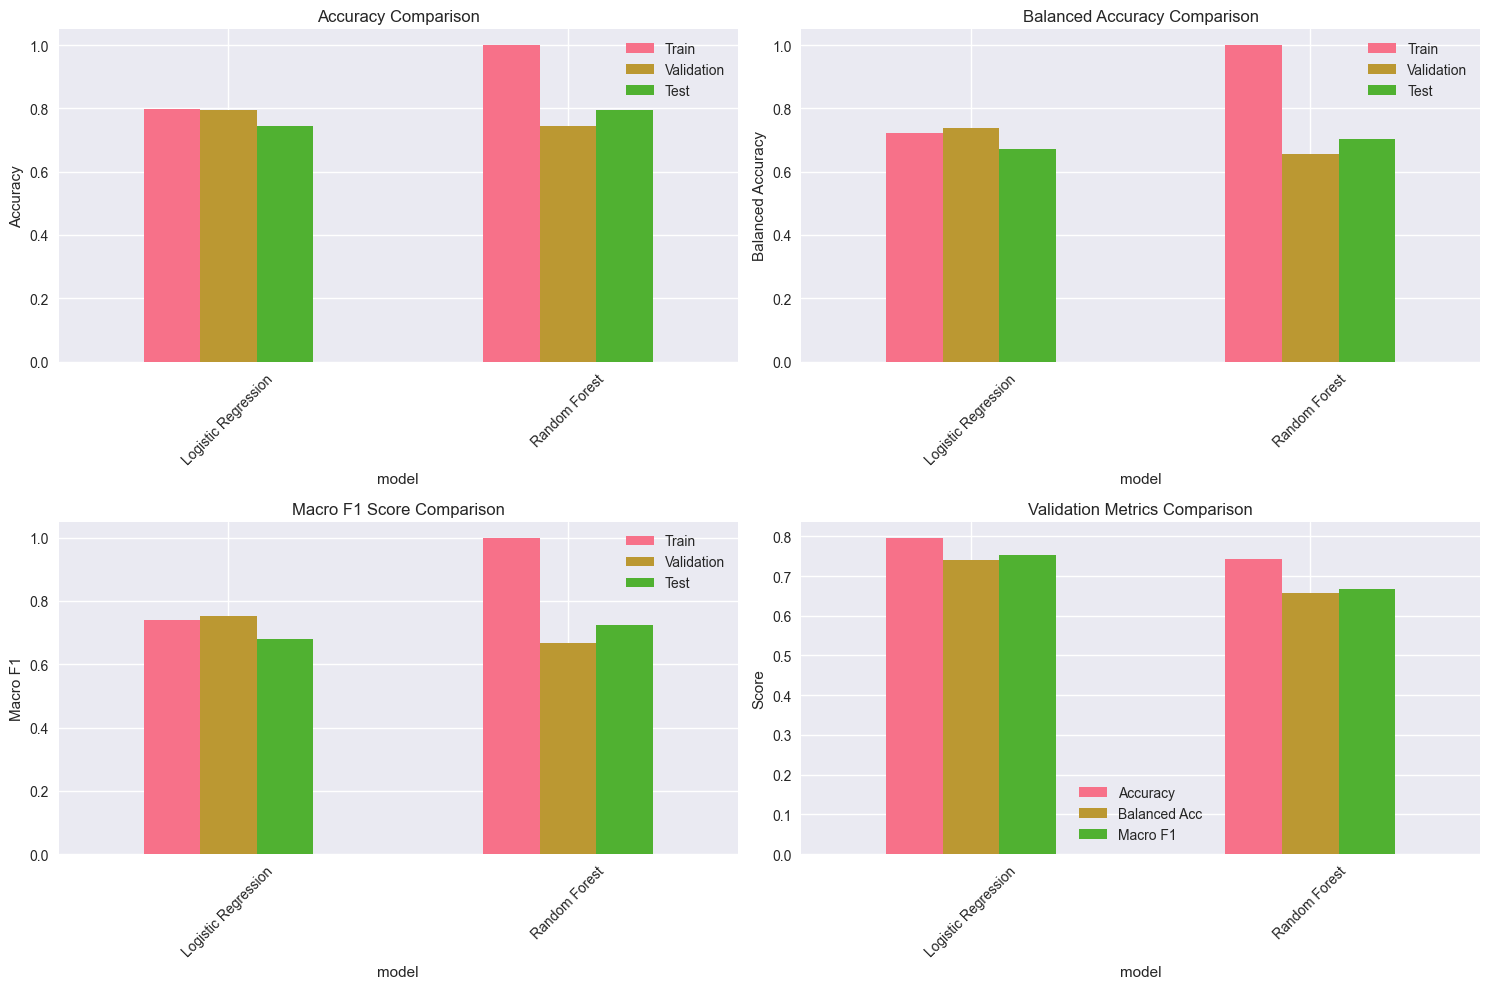

...Model comparison completed!


In [67]:

print("MODEL COMPARISON AND EVALUATION")

# Collect all results
all_results = [baseline_results, rf_results]
if xgb_results is not None:
    all_results.append(xgb_results)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.set_index('model')

print("\nModel Performance Comparison:")
print("=" * 80)
print(f"{'Model':<15} {'Train Acc':<10} {'Val Acc':<10} {'Test Acc':<10} {'Val F1':<10} {'Test F1':<10}")
print("=" * 80)
for _, row in comparison_df.iterrows():
    print(f"{row.name:<15} {row['train_accuracy']:<10.3f} {row['val_accuracy']:<10.3f} {row['test_accuracy']:<10.3f} {row['val_f1']:<10.3f} {row['test_f1']:<10.3f}")

# Find best model based on validation F1 score (EDA recommendation)
best_model_name = comparison_df['val_f1'].idxmax()
best_model_score = comparison_df.loc[best_model_name, 'val_f1']

print(f"\nBest Model: {best_model_name} (Validation F1: {best_model_score:.3f})")

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
comparison_df[['train_accuracy', 'val_accuracy', 'test_accuracy']].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(['Train', 'Validation', 'Test'])
axes[0,0].tick_params(axis='x', rotation=45)

# Balanced Accuracy comparison
comparison_df[['train_balanced_acc', 'val_balanced_acc', 'test_balanced_acc']].plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Balanced Accuracy Comparison')
axes[0,1].set_ylabel('Balanced Accuracy')
axes[0,1].legend(['Train', 'Validation', 'Test'])
axes[0,1].tick_params(axis='x', rotation=45)

# F1 Score comparison
comparison_df[['train_f1', 'val_f1', 'test_f1']].plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Macro F1 Score Comparison')
axes[1,0].set_ylabel('Macro F1')
axes[1,0].legend(['Train', 'Validation', 'Test'])
axes[1,0].tick_params(axis='x', rotation=45)

# Validation metrics only
validation_metrics = comparison_df[['val_accuracy', 'val_balanced_acc', 'val_f1']]
validation_metrics.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Validation Metrics Comparison')
axes[1,1].set_ylabel('Score')
axes[1,1].legend(['Accuracy', 'Balanced Acc', 'Macro F1'])
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("...Model comparison completed!")


DETAILED EVALUATION OF BEST MODEL
Best Model: Logistic Regression
Validation F1 Score: 0.752

Detailed Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.63      0.47      0.54        36
           1       0.78      0.87      0.82        77

    accuracy                           0.74       113
   macro avg       0.70      0.67      0.68       113
weighted avg       0.73      0.74      0.73       113


Confusion Matrix for Logistic Regression:
[[17 19]
 [10 67]]


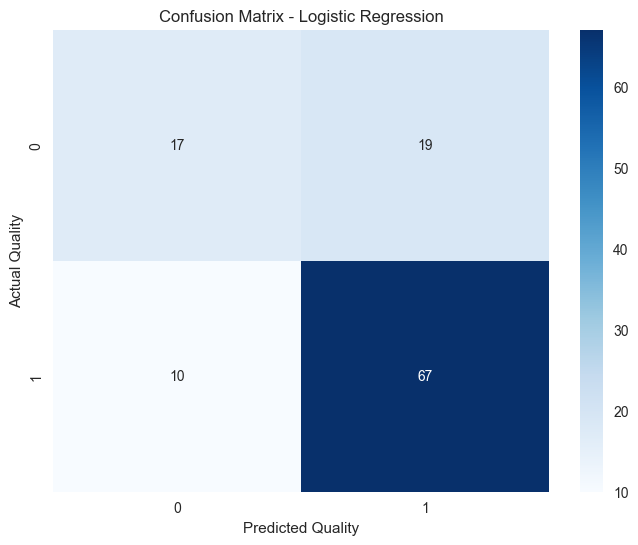


Per-class Performance for Logistic Regression:
Quality 0: 0.472 accuracy (36 samples)
Quality 1: 0.870 accuracy (77 samples)
...Detailed evaluation completed!


In [68]:
# Detailed evaluation of best model
print("DETAILED EVALUATION OF BEST MODEL")

# Get the best model
if best_model_name == 'Logistic Regression':
    best_model = baseline_model
    y_test_pred_best = y_test_pred
elif best_model_name == 'Random Forest':
    best_model = rf_model
    y_test_pred_best = y_test_pred_rf
elif best_model_name == 'XGBoost':
    best_model = xgb_model
    y_test_pred_best = y_test_pred_xgb

print(f"Best Model: {best_model_name}")
print(f"Validation F1 Score: {best_model_score:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report for {best_model_name}:")
print("=" * 60)
print(classification_report(y_test, y_test_pred_best))

# Confusion matrix
print(f"\nConfusion Matrix for {best_model_name}:")
cm = confusion_matrix(y_test, y_test_pred_best)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()), 
            yticklabels=sorted(y_test.unique()))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

# Per-class performance
print(f"\nPer-class Performance for {best_model_name}:")
unique_classes = sorted(y_test.unique())
for class_label in unique_classes:
    class_mask = y_test == class_label
    if class_mask.sum() > 0:  # Only if class exists in test set
        class_accuracy = accuracy_score(y_test[class_mask], y_test_pred_best[class_mask])
        print(f"Quality {class_label}: {class_accuracy:.3f} accuracy ({class_mask.sum()} samples)")

print("...Detailed evaluation completed!")
